Chapter 32
# 高斯朴素贝叶斯
Book_1《编程不难》 | 鸢尾花书：从加减乘除到机器学习  

##贝叶斯定理

高斯朴素贝叶斯分类 (Gaussian Naive Bayes, GNB) 是一种基于贝叶斯定理 (Bayes'
theorem) 的分类算法。

贝叶斯定理是一种概率论中用于计算条件概率的重要公式。它描述了在已知某个条件下，另一事件发生的概率。根据贝叶斯定
理，我们可以通过已知的先验概率和条件概率，来计算更新后的后验概率。这个定理在统计学、机器学习和人工智能等领域广泛
应用，尤其在贝叶斯推断和贝叶斯分类中起着重要作用。

贝叶斯定理、贝叶斯分类、贝叶斯推断中有两个重要概念——先验概率 (prior probability,
prior)、后验概率 (posterior probability, posterior)。


先验概率是指在考虑任何新证据之前，我们对一个事件或假设的概率的初始估计。它基于以前的经
验、先前的观察或领域知识。这种概率是“先验”的，因为它不考虑新数据或新证据，只是基于我们事先
已经了解的信息。


假设我们要研究某地区的流感发病率。在流感季节之前，我们可能会查阅历史数据、了解流感传播
的模式以及人口的健康状况，从而得出在流感季节中某人患上流感的初始估计概率，这就是先验概率。


后验概率是指在考虑了新证据或数据后，我们对一个事件或假设的概率进行更新后的估计。在得到
新的信息后，我们根据贝叶斯定理来更新先验概率，以得到后验概率。贝叶斯定理将先验概率和新的证
据结合起来，提供了一个更准确的概率估计。



在流感季节中，我们开始收集实际发病数据，比如每天有多少人确诊患上流感。根据这些新数据，
我们可以使用贝叶斯定理来更新先前的先验概率，得到一个更准确的后验概率，以更好地预测未来发病
率或做出相关决策。


高斯朴素贝叶斯分类假设每个特征在给定类别下是条件独立的，即给定类别的情况下，每个特征与
其他特征之间条件独立。这便是高斯朴素贝叶斯分类中“朴素”两个字的来由。然后，将每个类别的特征
分布建模为高斯分布，这则是高斯朴素贝叶斯分类中“高斯”两个字的来由。
以图 5 为例，给定标签为 C1 (红色点)，分别独立获得 fX1|Y(x1 | C1) 和 fX2|Y(x2 | C1)。假设条件独立，
fY,X1,X2(C1, x1, x2) = pY(C1)·fX1|Y(x1 | C1)·fX2|Y(x2 | C1)。

以图 5 为例，给定标签为 C1 (红色点)，分别独立获得 fX1|Y(x1 | C1) 和 fX2|Y(x2 | C1)。假设条件独立，
fY,X1,X2(C1, x1, x2) = pY(C1)·fX1|Y(x1 | C1)·fX2|Y(x2 | C1)。

##似然概率 (likelihood)

在训练时，算法从训练数据中学习每个类别的各个特征的 (条件) 均值和方差，用于计算每个特
征在该类别下的概率密度函数，即似然概率 (likelihood)。


当有新的未标记样本输入时，算法将计算该样本在每个类别下的条件概率 (后验概率)，并选择具
有最高概率的类别作为预测结果

高斯朴素贝叶斯分类算法的优点是简单快速、易于实现和适用于高维数据。它还能够处理连续型数
据，因为它假设数据分布是高斯分布

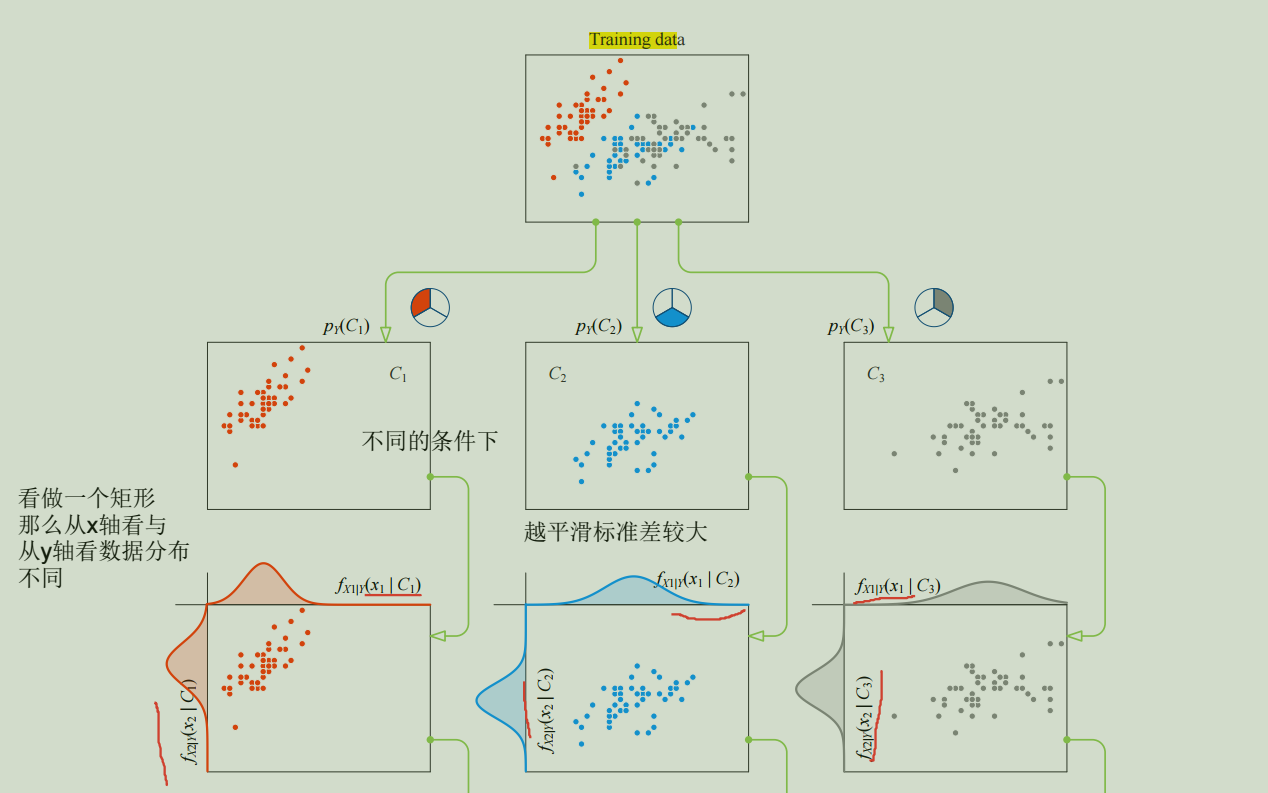

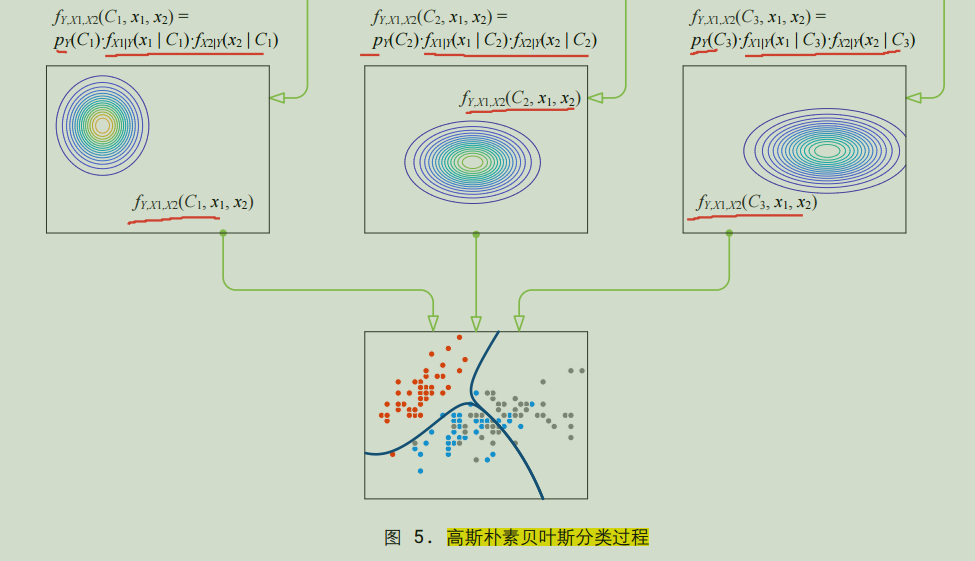

看做一个矩形
那么从x轴看与
从y轴看数据分布
不同

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap # 颜色映射
from sklearn import neighbors, datasets

# 导入并整理数据

In [4]:
# 导入并整理数据
iris = datasets.load_iris()
X = iris.data[:, :2]
y = iris.target

In [5]:
# 生成网格化数据
x1_array = np.linspace(4,8,101)
x2_array = np.linspace(1,5,101)
xx1, xx2 = np.meshgrid(x1_array,x2_array)

### 创建色谱

可视化效果对比
元素	使用的颜色映射	效果
预测区域（背景）	cmap_light（浅色）	柔和的背景色，不干扰数据点
真实数据点（前景）	cmap_bold（鲜艳）	鲜明的点，易于识别分类

In [7]:
# 创建色谱
rgb = [[255, 238, 255],   # 每一行为一个颜色
       [219, 238, 244],
       [228, 228, 228]]
rgb = np.array(rgb)/255. # 归一化
# cmap_light：区域（浅色背景）→ 模型如何划分空间
# cmap_bold：用于数据点本身
cmap_light = ListedColormap(rgb) # 创建离散色谱，即颜色映射，展示鸢尾花预测分类的区域。
cmap_bold = [[255, 51, 0],  # 区域颜色
             [0, 153, 255],
             [138,138,138]]
cmap_bold = np.array(cmap_bold)/255.

In [8]:
from sklearn.naive_bayes import GaussianNB #高斯朴素贝叶斯分类算法
# 创建高斯朴素贝叶斯分类器对象
gnb = GaussianNB() #
gnb.fit(X, y) #进行预测；数据与标签
# 用高斯朴素贝叶斯分类器对一系列查询点进行预测
q = np.c_[xx1.ravel(), xx2.ravel()]
y_predict = gnb.predict(q)
y_predict = y_predict.reshape(xx1.shape)

In [10]:
y_predict

array([[1, 1, 1, ..., 2, 2, 2],
       [1, 1, 1, ..., 2, 2, 2],
       [1, 1, 1, ..., 2, 2, 2],
       ...,
       [0, 0, 0, ..., 2, 2, 2],
       [0, 0, 0, ..., 2, 2, 2],
       [0, 0, 0, ..., 2, 2, 2]])

# 可视化

## 注意预测的值；也就是标签不一样了；与之前有一定的区别

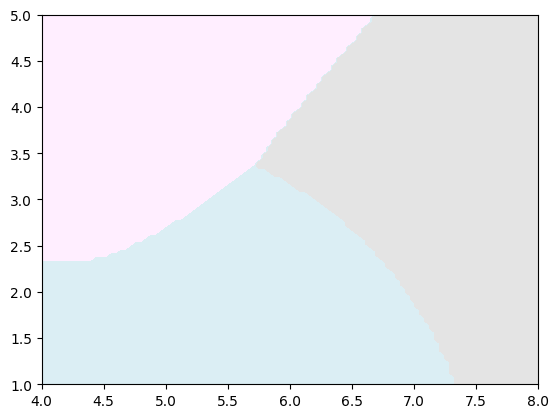

In [9]:
fig, ax = plt.subplots()
plt.contourf(xx1, xx2, y_predict, cmap=cmap_light)

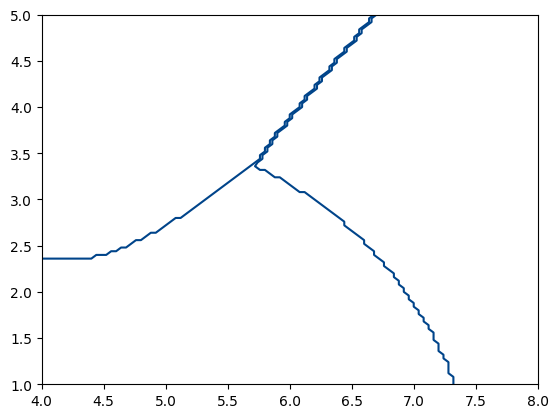

In [11]:
# 可视化
fig, ax = plt.subplots()
#plt.contourf(xx1, xx2, y_predict, cmap=cmap_light)
plt.contour(xx1, xx2, y_predict, levels=[0,1,2],
            colors=np.array([0, 68, 138])/255.)

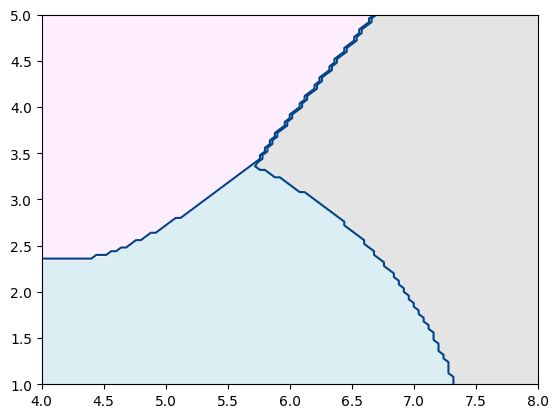

In [12]:
# 可视化
fig, ax = plt.subplots()
plt.contourf(xx1, xx2, y_predict, cmap=cmap_light)
plt.contour(xx1, xx2, y_predict, levels=[0,1,2],
            colors=np.array([0, 68, 138])/255.)

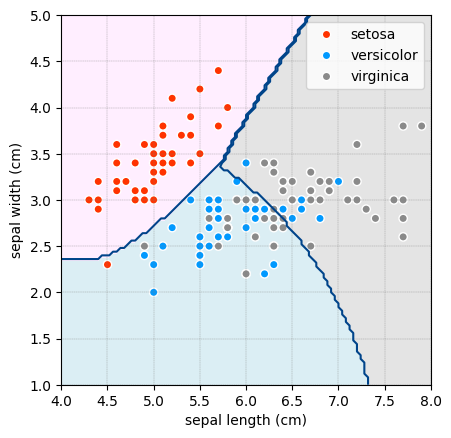

In [13]:
# 可视化
fig, ax = plt.subplots()
# 绘制等高线
plt.contourf(xx1, xx2, y_predict, cmap=cmap_light)
plt.contour(xx1, xx2, y_predict, levels=[0,1,2],
            colors=np.array([0, 68, 138])/255.)
# 绘制数据点
sns.scatterplot(x=X[:, 0], y=X[:, 1],
                hue=iris.target_names[y], # 按照 'species' 列的值对数据点进行颜色分类
                ax = ax, # 轴对象
                palette=dict(setosa=cmap_bold[0,:], #设置颜色配色方案
                versicolor=cmap_bold[1,:],
                virginica=cmap_bold[2,:]),
                alpha=1.0,
                linewidth = 1, edgecolor=[1,1,1]) #边缘为白色
plt.xlim(4, 8); plt.ylim(1, 5)# 范围
plt.xlabel(iris.feature_names[0]) # 标签
plt.ylabel(iris.feature_names[1])
ax.grid(linestyle='--', linewidth=0.25,  # 网格格式
        color=[0.5,0.5,0.5])
ax.set_aspect('equal', adjustable='box') #x,y轴比例一致